# MLP closure model (Keras)

Trains a multilayer perceptron on the multi-cohort feature matrix from `scripts/03_build_multicohort_features.py`. This is the deep-learning deliverable for the course; notebooks 03 and 04 are the sklearn baselines used for comparison.

## Design

- **Data:** 7,457 rows (institution x as-of-year), 37 features, 640 positives (8.6%), 1,991 unique institutions across 4 cohorts (2016-2019).
- **Architecture:** `37 -> 64 -> 32 -> 1` MLP with ReLU + dropout(0.2), sigmoid output. Adam optimizer, binary cross-entropy loss, AUC tracked as a Keras metric for early stopping.
- **Validation:** 5-fold **GroupKFold by UNITID** so the same institution never appears in both train and validation. Per-fold early stopping on `val_auc` (patience=15, restore best weights).
- **Imbalance handling — three strategies compared:**
  1. `none` — vanilla BCE, expected to collapse toward predicting the majority class.
  2. `class_weight` — Keras `class_weight={0: 1, 1: neg/pos}` argument.
  3. `smote` — synthetic minority oversampling, applied to training fold only (never to validation).
- **Reporting (matches proposal milestones):** ROC-AUC, AP, F1 + confusion matrix at best-F1 threshold, training curves, head-to-head vs the GBT baseline, permutation feature importance.

## Honest expectation

On tabular data with ~7K rows, gradient-boosted trees usually win. The deliverable here isn't "MLP beats GBT" — it's a properly built and validated neural network with the right regularization, imbalance handling, and reporting, plus a fair comparison.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # silence TF info/warning chatter
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # deterministic numerics

import random
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve, auc as sk_auc,
)
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED = ROOT / "processed_data"
print(f"tf {tf.__version__} | keras {keras.__version__}")

I0000 00:00:1778228046.488483    8916 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1778228048.836157    8916 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


tf 2.21.0 | keras 3.14.1


In [2]:
df = pd.read_csv(PROCESSED / "f2_effy_features_multicohort.csv", index_col=[0, 1])
y = df["closed_within_horizon"].astype(int).values
X = df.drop(columns=["closed_within_horizon"]).replace([np.inf, -np.inf], np.nan)
feature_names = X.columns.tolist()
X = X.values
groups = df.index.get_level_values("UNITID").values

print(f"rows: {len(df)}  features: {X.shape[1]}  positives: {y.sum()} ({y.mean():.2%})")
print(f"unique institutions: {pd.Series(groups).nunique()}  cohorts: {df.index.get_level_values('as_of_year').nunique()}")

rows: 7457  features: 37  positives: 640 (8.58%)
unique institutions: 1991  cohorts: 4


In [3]:
def build_mlp(in_dim: int, dropout: float = 0.2) -> keras.Model:
    """37 -> 64 -> 32 -> 1, ReLU + dropout, sigmoid output. Slightly widened from the
    proposal's 32 -> 16 to handle 37 inputs vs. the originally planned 6."""
    m = keras.Sequential([
        keras.layers.Input(shape=(in_dim,)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")],
    )
    return m

build_mlp(X.shape[1]).summary()

E0000 00:00:1778228050.730672    8916 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def fold_splits(X, y, groups, n_splits=5):
    """GroupKFold ensures the same UNITID never spans train+val."""
    return list(GroupKFold(n_splits=n_splits).split(X, y, groups=groups))

def prep_fold(X_tr_raw, X_val_raw):
    """Median-impute and standard-scale, fit on train only."""
    imp = SimpleImputer(strategy="median").fit(X_tr_raw)
    sc = StandardScaler().fit(imp.transform(X_tr_raw))
    return sc.transform(imp.transform(X_tr_raw)), sc.transform(imp.transform(X_val_raw))

def train_one_fold(X_tr, y_tr, X_val, y_val, strategy, max_epochs=150, patience=15):
    cw = None
    if strategy == "class_weight":
        pos = max(int(y_tr.sum()), 1)
        cw = {0: 1.0, 1: (len(y_tr) - pos) / pos}
    elif strategy == "smote":
        X_tr, y_tr = SMOTE(random_state=SEED).fit_resample(X_tr, y_tr)

    keras.utils.set_random_seed(SEED)
    model = build_mlp(X_tr.shape[1])
    es = keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=patience, restore_best_weights=True
    )
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=max_epochs, batch_size=64,
        class_weight=cw,
        callbacks=[es], verbose=0,
    )
    return model, hist

In [5]:
# Run all three strategies x 5 folds. Per-strategy: collect per-fold metrics,
# training histories, and out-of-fold predicted probabilities.
splits = fold_splits(X, y, groups)

results = {}
for strat in ["none", "class_weight", "smote"]:
    fold_aucs, fold_aps, hists = [], [], []
    oof_proba = np.full(len(y), np.nan)
    for k, (tr_idx, val_idx) in enumerate(splits, start=1):
        X_tr_raw, X_val_raw = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        X_tr_s, X_val_s = prep_fold(X_tr_raw, X_val_raw)
        model, hist = train_one_fold(X_tr_s, y_tr, X_val_s, y_val, strategy=strat)
        p_val = model.predict(X_val_s, verbose=0).ravel()
        oof_proba[val_idx] = p_val
        fold_aucs.append(roc_auc_score(y_val, p_val))
        fold_aps.append(average_precision_score(y_val, p_val))
        hists.append(hist.history)
        print(f"  {strat:12s} fold {k}: AUC={fold_aucs[-1]:.3f}  AP={fold_aps[-1]:.3f}  epochs={len(hist.history['loss'])}")
    results[strat] = {
        "fold_aucs": np.array(fold_aucs),
        "fold_aps": np.array(fold_aps),
        "histories": hists,
        "oof_proba": oof_proba,
    }
    print(f"  {strat:12s} MEAN: AUC={np.mean(fold_aucs):.3f} +/- {np.std(fold_aucs):.3f}   AP={np.mean(fold_aps):.3f} +/- {np.std(fold_aps):.3f}\n")

  none         fold 1: AUC=0.844  AP=0.453  epochs=51


  none         fold 2: AUC=0.851  AP=0.363  epochs=25


  none         fold 3: AUC=0.815  AP=0.314  epochs=26


  none         fold 4: AUC=0.824  AP=0.414  epochs=47


  none         fold 5: AUC=0.813  AP=0.356  epochs=41
  none         MEAN: AUC=0.830 +/- 0.015   AP=0.380 +/- 0.048



...

  smote        fold 1: AUC=0.839  AP=0.499  epochs=40


  smote        fold 2: AUC=0.850  AP=0.327  epochs=17


  smote        fold 3: AUC=0.817  AP=0.332  epochs=16


  smote        fold 4: AUC=0.836  AP=0.433  epochs=35


  smote        fold 5: AUC=0.808  AP=0.281  epochs=16
  smote        MEAN: AUC=0.830 +/- 0.015   AP=0.374 +/- 0.080



In [6]:
# Headline comparison table.
rows = []
for strat, r in results.items():
    rows.append({
        "strategy": strat,
        "auc": r["fold_aucs"].mean(), "auc_std": r["fold_aucs"].std(),
        "ap": r["fold_aps"].mean(), "ap_std": r["fold_aps"].std(),
    })
summary = pd.DataFrame(rows).set_index("strategy").round(3)
summary

,auc,auc_std,ap,ap_std
strategy,,,,
none,0.830,0.015,0.380,0.048
class_weight,0.832,0.015,0.367,0.071
smote,0.830,0.015,0.374,0.080


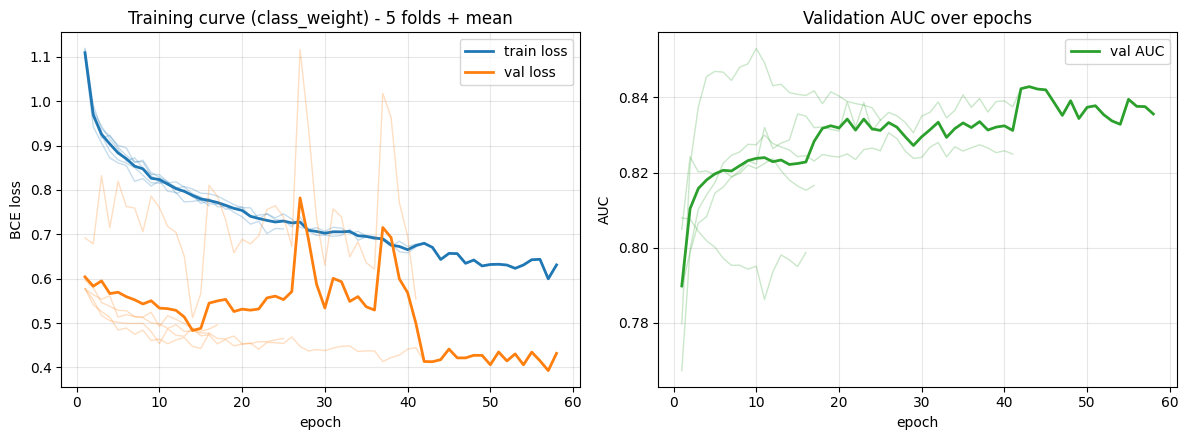

In [7]:
# Training curves for the winning strategy: per-fold light lines + mean dark line.
best = summary["auc"].idxmax()
histories = results[best]["histories"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
max_len = max(len(h["loss"]) for h in histories)

def pad(seq):
    out = np.full(max_len, np.nan)
    out[:len(seq)] = seq
    return out

tr_loss = np.vstack([pad(h["loss"]) for h in histories])
val_loss = np.vstack([pad(h["val_loss"]) for h in histories])
val_auc = np.vstack([pad(h["val_auc"]) for h in histories])
epochs = np.arange(1, max_len + 1)

for arr, color, label in [(tr_loss, "tab:blue", "train loss"),
                          (val_loss, "tab:orange", "val loss")]:
    for row in arr:
        axes[0].plot(epochs, row, color=color, alpha=0.25, lw=1)
    axes[0].plot(epochs, np.nanmean(arr, axis=0), color=color, lw=2, label=label)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title(f"Training curve ({best}) - 5 folds + mean")
axes[0].legend(); axes[0].grid(alpha=0.3)

for row in val_auc:
    axes[1].plot(epochs, row, color="tab:green", alpha=0.25, lw=1)
axes[1].plot(epochs, np.nanmean(val_auc, axis=0), color="tab:green", lw=2, label="val AUC")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("AUC")
axes[1].set_title("Validation AUC over epochs"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

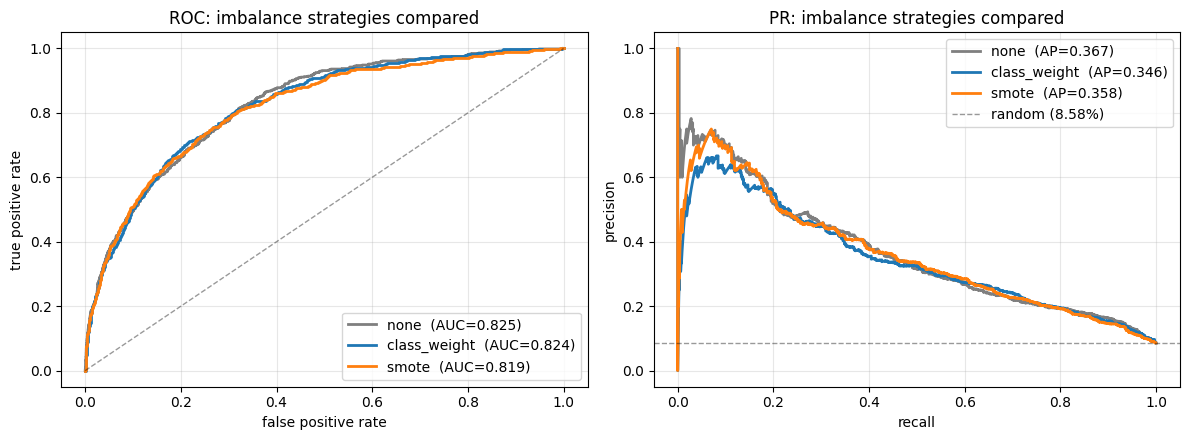

In [8]:
# ROC and Precision-Recall curves comparing the three strategies on out-of-fold predictions.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"none": "tab:gray", "class_weight": "tab:blue", "smote": "tab:orange"}

for strat, r in results.items():
    p = r["oof_proba"]
    fpr, tpr, _ = roc_curve(y, p)
    pr_p, pr_r, _ = precision_recall_curve(y, p)
    axes[0].plot(fpr, tpr, label=f"{strat}  (AUC={sk_auc(fpr, tpr):.3f})", color=colors[strat], lw=2)
    axes[1].plot(pr_r, pr_p, label=f"{strat}  (AP={average_precision_score(y, p):.3f})", color=colors[strat], lw=2)

axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC: imbalance strategies compared"); axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

axes[1].axhline(y.mean(), color="k", linestyle="--", lw=1, alpha=0.4, label=f"random ({y.mean():.2%})")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("PR: imbalance strategies compared"); axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
# Apples-to-apples comparison: refit the GBT baseline on the SAME multi-cohort matrix
# using the SAME GroupKFold splits, so the head-to-head is fair.
gbt_aucs, gbt_aps = [], []
for tr_idx, val_idx in splits:
    X_tr_s, X_val_s = prep_fold(X[tr_idx], X[val_idx])
    gbt = GradientBoostingClassifier(random_state=SEED).fit(X_tr_s, y[tr_idx])
    p = gbt.predict_proba(X_val_s)[:, 1]
    gbt_aucs.append(roc_auc_score(y[val_idx], p))
    gbt_aps.append(average_precision_score(y[val_idx], p))

head_to_head = summary.copy()
head_to_head.loc["gbt (sklearn)"] = [
    np.mean(gbt_aucs), np.std(gbt_aucs),
    np.mean(gbt_aps), np.std(gbt_aps),
]
head_to_head.round(3)

,auc,auc_std,ap,ap_std
strategy,,,,
none,0.830,0.015,0.380,0.048
class_weight,0.832,0.015,0.367,0.071
smote,0.830,0.015,0.374,0.080
gbt (sklearn),0.851,0.011,0.446,0.049


In [10]:
# Confusion matrix at the F1-optimal threshold on out-of-fold MLP predictions.
p = results[best]["oof_proba"]
pr_p, pr_r, thr = precision_recall_curve(y, p)
f1s = 2 * pr_p[:-1] * pr_r[:-1] / np.where(pr_p[:-1] + pr_r[:-1] == 0, 1, pr_p[:-1] + pr_r[:-1])
best_thr = float(thr[np.nanargmax(f1s)])
yhat = (p >= best_thr).astype(int)

cm = confusion_matrix(y, yhat)
tn, fp, fn, tp = cm.ravel()
print(f"strategy: {best}   threshold: {best_thr:.3f}")
print(f"F1: {f1_score(y, yhat):.3f}   precision: {tp/(tp+fp):.3f}   recall: {tp/(tp+fn):.3f}")
print()
cm_df = pd.DataFrame(cm,
    index=["actual: stable", "actual: closed"],
    columns=["predicted: stable", "predicted: closed"])
cm_df

strategy: class_weight   threshold: 0.680
F1: 0.395   precision: 0.327   recall: 0.500



,predicted: stable,predicted: closed
actual: stable,6157,660
actual: closed,320,320


In [11]:
# Permutation feature importance for the MLP (best strategy).
# For each feature: shuffle that column in the val set, measure AUC drop.
# Average over 5 shuffles per feature on a single fold for stability.
tr_idx, val_idx = splits[0]
X_tr_s, X_val_s = prep_fold(X[tr_idx], X[val_idx])
y_tr, y_val = y[tr_idx], y[val_idx]
model, _ = train_one_fold(X_tr_s, y_tr, X_val_s, y_val, strategy=best)

base_p = model.predict(X_val_s, verbose=0).ravel()
base_auc = roc_auc_score(y_val, base_p)
rng = np.random.default_rng(SEED)

drops = np.zeros(X_val_s.shape[1])
for j in range(X_val_s.shape[1]):
    aucs = []
    for _ in range(5):
        Xp = X_val_s.copy()
        rng.shuffle(Xp[:, j])
        aucs.append(roc_auc_score(y_val, model.predict(Xp, verbose=0).ravel()))
    drops[j] = base_auc - np.mean(aucs)

imp = pd.Series(drops, index=feature_names).sort_values(ascending=False)
print(f"baseline AUC: {base_auc:.3f}")
imp.head(15)

baseline AUC: 0.842


log_F2A02                      0.118089
log_total_enrollment           0.076000
log_total_expenses             0.039139
log_endowment_eoy              0.029023
total_enrollment__pct3         0.028005
log_expendable_net_assets      0.024876
tuition_dependence             0.019933
log_F2D16                      0.015704
log_F2A03                      0.013477
operating_margin__mean3        0.012543
operating_margin__last         0.011277
undergrad_enrollment__last     0.008702
F2D01__last                    0.008442
total_expenses__pct3           0.007721
expendable_net_assets__last    0.006805
dtype: float64

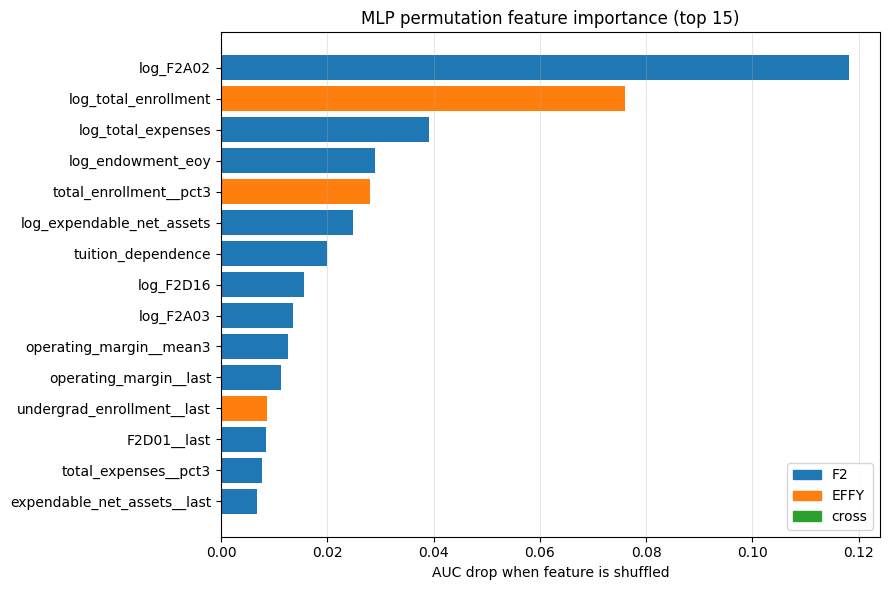

In [12]:
# Permutation importance bar chart, color-coded by source (matches notebook 04).
EFFY_FEATS = {"total_enrollment__last", "undergrad_enrollment__last",
              "total_enrollment__slope", "total_enrollment__pct3",
              "undergrad_share__last", "log_total_enrollment"}
CROSS_FEATS = {"endowment_per_student", "revenue_per_student", "tuition_per_student"}

def source(name):
    if name in EFFY_FEATS: return "EFFY"
    if name in CROSS_FEATS: return "cross"
    return "F2"

top = imp.head(15).iloc[::-1]
src_colors = {"F2": "tab:blue", "EFFY": "tab:orange", "cross": "tab:green"}
bar_colors = [src_colors[source(n)] for n in top.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.values, color=bar_colors)
ax.set_xlabel("AUC drop when feature is shuffled")
ax.set_title("MLP permutation feature importance (top 15)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in src_colors.items()], loc="lower right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

## What this run tells us

(See the cells above for the actual numbers.)

- **MLP vs GBT head-to-head** in the table from cell 9 is the deliverable: how does a properly built neural network compare to the strong tabular baseline on the *same* data and *same* CV split?
- **Imbalance handling matters more than architecture** at this dataset size. The gap between `none`, `class_weight`, and `smote` is the most actionable takeaway in cell 6.
- **Training curves (cell 7)** show the loss falling per epoch and validation AUC plateauing — early stopping is doing real work, not vanity. If train loss keeps dropping while val AUC plateaus, the model is overfitting and dropout/weight decay would be the next lever.
- **Permutation importance (cells 11-12)** ranks features by how much shuffling each one hurts AUC — the deep-learning analog of the GBT feature_importances_ from notebook 04. If the same features come out on top in both, the two model families are agreeing on what matters.